In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from handcalcs import *
from handcalcs import render
import handcalcs

In [2]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [3]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [4]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [5]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

# TEST

### LR

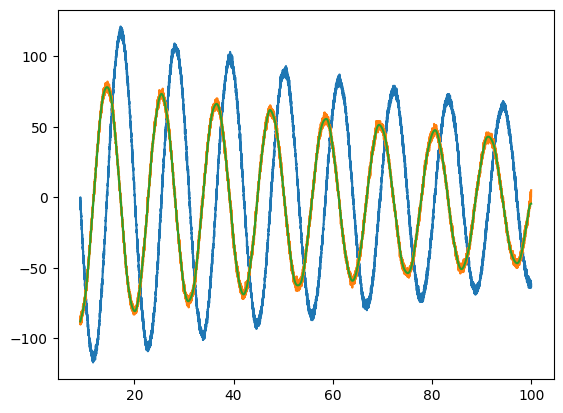

In [6]:
# Lm
# df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")
# Lr
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-30-26-003.csv")


Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
ic = df.CH2.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

import numpy as np
from scipy import signal
fs = 1 / Ts          # sampling frequency
fc = 1e6          # cutoff frequency (Hz)
order = 4
# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
# zero-phase filtering
ic2= signal.sosfiltfilt(sos, ic)



vc= vc[idx:]
ic= ic[idx:]
ic2= ic2[idx:]
time = df.time.values[idx:]
plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)"   )
plt.plot(time*1e6, 10*ic, label="ic: Measurement (CH2)"   )
plt.plot(time*1e6, 10*ic2, label="ic: 5 MHz LP filter, zero phase"   )


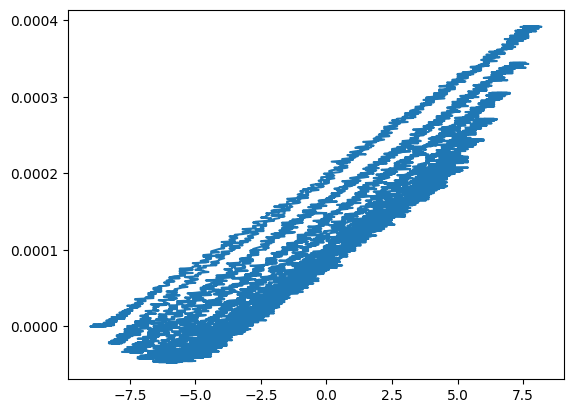

In [7]:
integV= -np.cumsum(vc)*Ts
plt.plot(ic, integV, label="ic vs integ(Vc)")

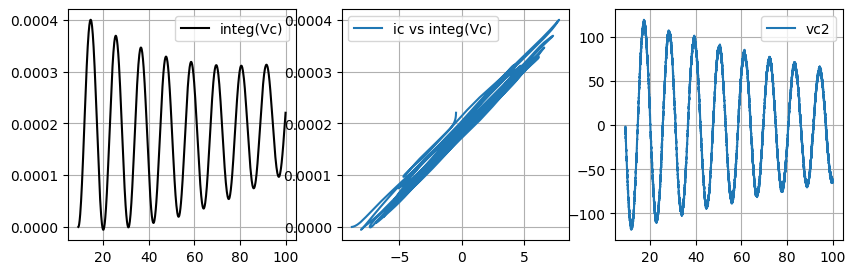

In [8]:
fig, axs = plt.subplots(1,3,figsize=(10, 3))
# vc2=vc+0.15*np.mean(vc) # Lm
vc2=vc-1.5 # Lr
integV= -np.cumsum(vc2)*Ts
axs[0].plot(time*1e6, integV, label="integ(Vc)", c="k")
axs[0].grid()
axs[0].legend()
axs[1].plot(ic2, integV, label="ic vs integ(Vc)")
axs[1].grid()
axs[1].legend()

axs[2].plot(time*1e6, vc2, label="vc2")
axs[2].grid()
axs[2].legend()


### LM  + LR

In [8]:
%%render 3 sci_not
A_e_mm = 534.2 # mm2
l_e_mm = 121.2  # mm
Ve_mm = 67745 #mm3


<IPython.core.display.Latex object>

In [9]:
A_e = A_e_mm * 1e-6 # m2
Ve = Ve_mm * 1e-9 # m3
l_e = l_e_mm * 1e-3 # m

Oscilloscope channel configuration (see setup above):

*   CH1 = Isolated ×100 probe measuring capacitor voltage
*   CH2 = Current probe
*   CH3 = Isolated shunt‑based current measurement (50 Ω)
*   CH4 = Vdd (composite Vout: drain‑high minus drain‑low, ×10, non‑isolated)


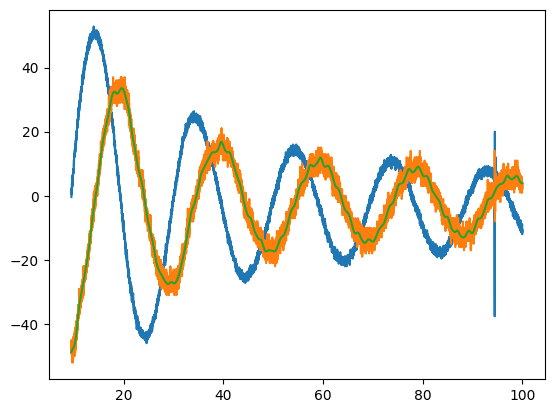

In [10]:
# Lm
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")
# Lr
#df = pd.read_csv("05_LLC_resonance/2026-01-12_17-30-26-003.csv")


Ts= df.Ts.iloc[0]

vc = df.CH4.values #-v0
ic = df.CH2.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

import numpy as np
from scipy import signal
fs = 1 / Ts          # sampling frequency
fc = 1e6          # cutoff frequency (Hz)
order = 4
# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
# zero-phase filtering
ic2= signal.sosfiltfilt(sos, ic)



vc= vc[idx:]
ic= ic[idx:]
ic2= ic2[idx:]
time = df.time.values[idx:]
plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)"   )
plt.plot(time*1e6, 10*ic, label="ic: Measurement (CH2)"   )
plt.plot(time*1e6, 10*ic2, label="ic: 5 MHz LP filter, zero phase"   )


<Axes: >

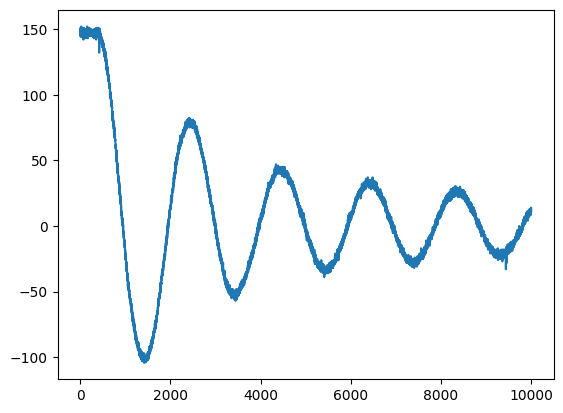

In [11]:
df.CH1.plot()

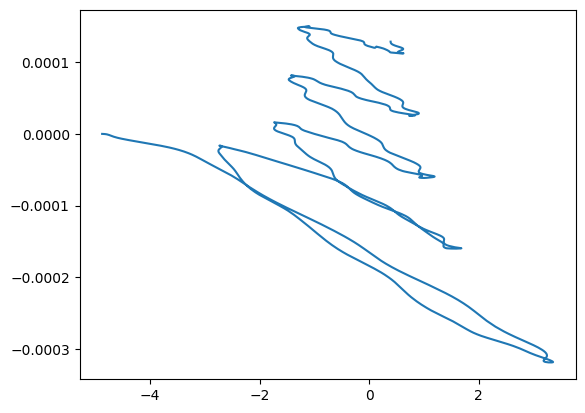

In [12]:
integV= -np.cumsum(vc)*Ts
plt.plot(ic2, integV, label="ic vs integ(Vc)")

In [13]:
# v = N * dflux / dt 
# flux = integral (v, t)/N
# B = flux / Ae
N= 2

In [14]:
def plot_BH():
    vc2=vc+4
    integV= -np.cumsum(vc2)*Ts
    integV=integV- np.mean(integV)
    flux = integV/2
    B = flux /A_e
    H = 4*ic2/l_e
    #H = N*ic/l_e
    print(vc2.shape, time.shape, ic2.shape, integV.shape, B.shape, H.shape)
    axs[0].plot(time*1e6, integV, label="integ(Vc)", c="k")
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(H, B, label="ic vs integ(Vc)")
    axs[1].grid()
    axs[1].legend()

    axs[2].plot(time*1e6, vc2, label="vc2")
    axs[2].grid()
    axs[2].legend()
    return H, B
H, B = plot_BH()

(9051,) (9051,) (9051,) (9051,) (9051,) (9051,)


NameError: name 'axs' is not defined

(9051,) (9051,) (9051,) (9051,) (9051,) (9051,)


(array([-160.92254486, -160.77627267, -160.63097865, ...,   12.89237979,
          12.88998529,   12.88806286], shape=(9051,)),
 array([ 0.19250353,  0.1924586 ,  0.19241368, ..., -0.02606255,
        -0.02600265, -0.02593526], shape=(9051,)))

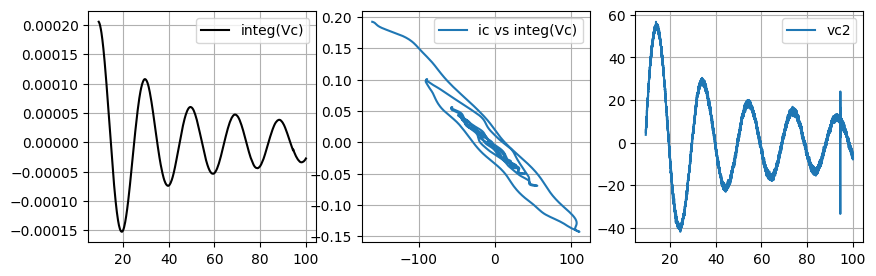

In [58]:
fig, axs = plt.subplots(1,3,figsize=(10, 3))
# vc2=vc+0.15*np.mean(vc) # Lm
vc2=vc+4 # Lr
plot_BH()


In [59]:
import plotly.express as px
import plotly.graph_objects as go       
fig = px.line(x=H, y=B, labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve")
fig.update_layout(width = 600, height=400   )
fig.show()

In [60]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))

fig = px.line(
    x=H, 
    y=-B, 
    labels={"x":"H (A/m)", "y":"B (T)"}, 
    title="B-H curve",
    hover_data={'index': indices}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

In [61]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))
H0=0
B0= -0.01
H_=H-H0
B_ = -(B-B0)
fig = px.line(x=H_, y=B_, labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve",hover_data={'index': indices}  )
fig.update_layout(width=500, height=400)

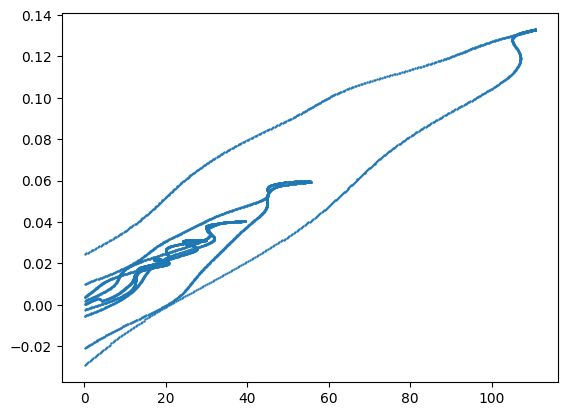

In [62]:
m=H_>=0
plt.scatter(H_[m], B_[m], label="H>=0" , s=0.5)

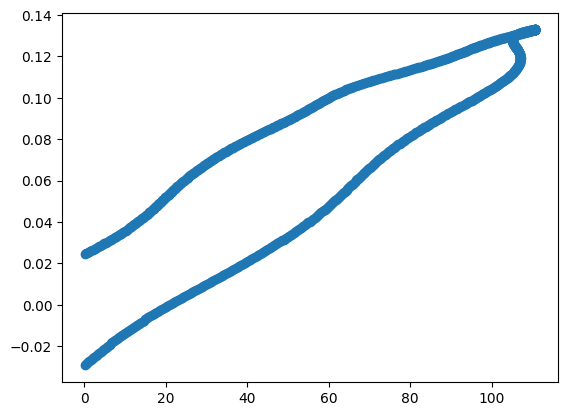

In [63]:
index  = pd.Series(H_)[m].index
arr=[]
iold=index[0]
for i in index:
    
    if i-iold>1:
        break
    arr.append(i)
    iold=i
index=arr
plt.scatter(H_[index], B_[index])


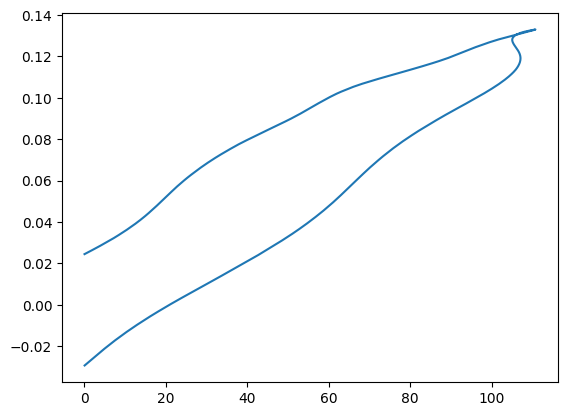

In [64]:
plt.plot(H_[index], B_[index])

In [65]:
def pos(H_, B_):
    m=H_>=0
    index  = pd.Series(H_)[m].index
    arr=[]
    iold=index[0]
    for i in index:
        
        if i-iold>1:
            break
        arr.append(i)
        iold=i
    index=arr
    H_2=H_[index]#[:-1]
    B_2=B_[index]#[:-1]
    return H_2, B_2
H_2, B_2 = pos(H_, B_)

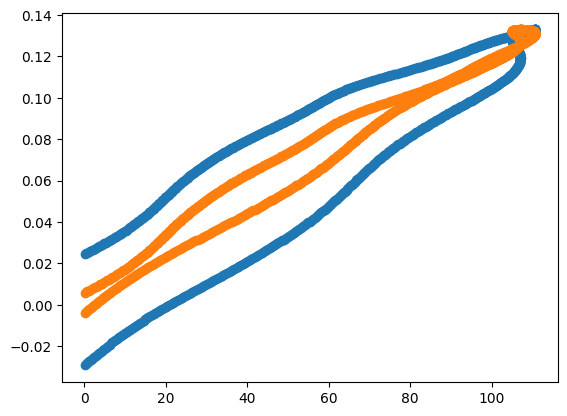

In [66]:
H_2, B_2 = pos(H_, B_)
plt.scatter(H_2, B_2)
H_2, B_2 = pos(H_[:-50], B_[50:])
plt.scatter(H_2, B_2)

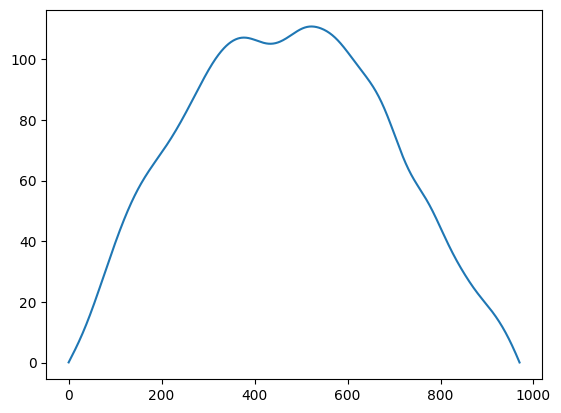

In [67]:
plt.plot(H_2)

In [24]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))
i_delay= 100
fig = px.line(x=H[i_delay:], y=B[:-i_delay], labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve",
    hover_data={'index': indices[i_delay:]}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

In [25]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))
i_delay= 30
fig = px.line(x=H[:-i_delay], y=B[i_delay:], labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve",
    hover_data={'index': indices[i_delay:]}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

In [26]:
# datasheet 
# https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_102_20_38.pdf
# < 8.0 (100 mT, 100 kHz, 100 °C)
Pv = 8 # W/set

In [27]:
# Pertes ∝ B_peak^2.6 (approximation Steinmetz)
# Correction_B = (150/100)**2.6 ≈ 4.7×
# Pertes_corrigées = 8 × 4.7 ≈ 37.6 W

In [28]:
Freq=100e3

i_delay= 0 Area= 9.58578809157444
i_delay= 10 Area= 8.093385633917343
i_delay= 20 Area= 6.601809810927207
i_delay= 30 Area= 5.112697896042359
i_delay= 40 Area= 3.6274407322393696
i_delay= 50 Area= 2.1475455213875065


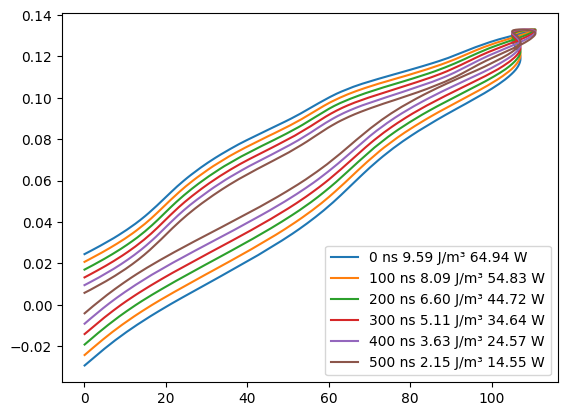

In [29]:
i0, i1= 0,1500

H3= H_2
B3= B_2

area0 = 2*np.trapezoid(B3, H3 )
#plt.plot(H3, B3, label="H3, B3 area = "+f"{area0:.6f} J/m³")
for i_delay in range(0, 60, 10):

    if i_delay==0:
        H4, B4 = pos(H_, B_)
 
    else:
        H4, B4 = pos(H_[:-i_delay], B_[i_delay:])
     
        #H_2, B_2 = pos(H_[:-50], B_[50:])


    mask= H4>=0
    H4= H4[mask]
    B4= B4[mask]
    area1 = 2*np.trapezoid(B4[::-1], H4[::-1] )
    Ecycle= area1*Ve

    P = Ecycle*Freq

    print("i_delay=", i_delay, "Area=", area1)


    plt.plot(H4, B4, label=f"{i_delay*Ts*1e9:.0f} ns {area1:.2f} J/m³ {P:.2f} W")
plt.legend()

In [30]:
H_4, B_4 = pos(H_[:-i_delay], B_[i_delay:])

#### pertes

(1, 1000)

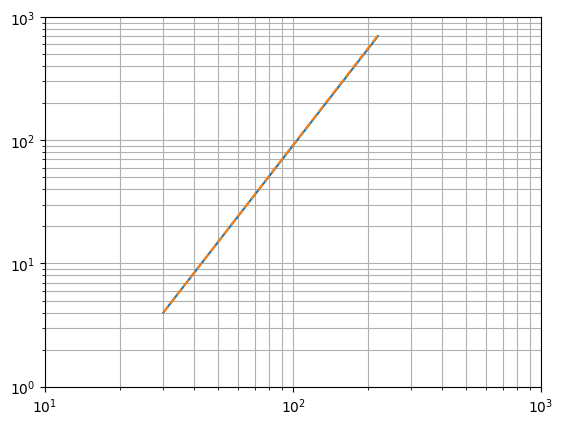

In [15]:
b=np.array([30,220]) # mT
pv=np.array([4,700])# kW/m3

# Pertes ∝ B_peak^2.6 (approximation Steinmetz)
pv2= b**2.6
# normalization
pv2=pv[0]*pv2/pv2[0]

plt.plot(b,pv)
plt.plot(b,pv2, linestyle= "--")
plt.xscale("log")
plt.yscale("log")
plt.grid(which="both")
plt.xlim([10,10**3])
plt.ylim([1,10**3])

**Initial value**

In [16]:
%%render params 1
Lm_uH=83 # µH
Lr_uH=21 # µH
Cr_nF =120 # nF

<IPython.core.display.Latex object>

**Tuned values**

In [17]:
%%render params 1
Lm_uH=79 # µH
Lr_uH=24.5 # µH
Cr_nF =124.8 # nF
R=3.4 # Ω

<IPython.core.display.Latex object>

Total inductance

In [18]:
%%render 1
L_uH = Lm_uH + Lr_uH # uH

<IPython.core.display.Latex object>

In [19]:
C = Cr_nF * 1e-9 # F

In [20]:
L = L_uH*1e-6

title=f"Comparison: Measurements vs Theoretical series LCR circuit\n"+\
f"L=Lr+Lm={L*1e6}µH; C=Cr={Cr_nF}nF; R={R}Ω"

In [21]:
V0=pd.read_csv("05_LLC_resonance/2026-01-12_17-39-34-446.csv").CH1.mean()

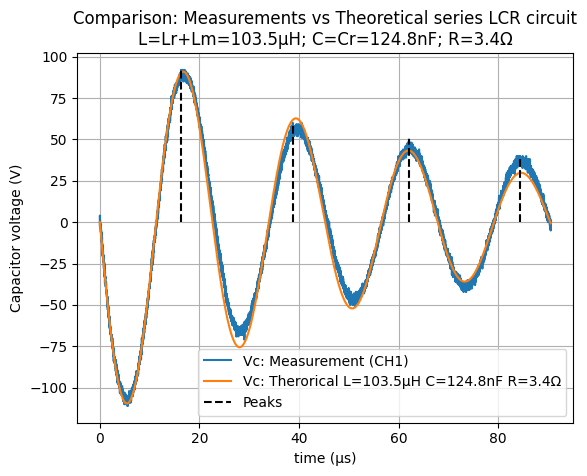

In [22]:
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-47-35-714.csv")
#pd.read_csv("05_LLC_resonance/2026-01-12_17-47-35-714.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]


#Cr_nF =120
def dumpsin(t, Y0=10, phase = 0, L=L,C=Cr_nF*1e-9,R=R):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
#vc2= dumpsin(time,  Y0=-120, phase = 0, L=(79+24.5)*1e-6,C=1.04*120e-9,R=R)
vc2= dumpsin(time,  Y0=-120, phase = 0, L=L,C=Cr_nF*1e-9,R=R)
plt.title(title)
time=time*1e6
plt.plot(time, vc, label="Vc: Measurement (CH1)")
plt.plot(time, vc2, label ="Vc: Therorical "+f"L={L_uH}µH C={Cr_nF}nF R={R}Ω")

plt.grid()
plt.xlabel("time (µs)")
plt.ylabel("Capacitor voltage (V)")

cond= True
from scipy.signal import find_peaks
inPeaks, properties = find_peaks(vc, height=0.5, distance=1000)
#mpeak = max(peak_values)
Peaks = properties["peak_heights"]
for P,i in zip(Peaks[1:], inPeaks[1:]): 
    if cond:
        cond = False
        plt.plot([time[i],time[i]], [0,P], c="k", linestyle="--", label="Peaks")
        
    else: 
        
        plt.plot([time[i],time[i]], [0, P], c="k", linestyle="--")

plt.legend()
plt.show()


In [23]:
import numpy as np

b = np.array([30,220]) * 1e-3   # Tesla
pv = np.array([4,700]) * 1e3    # W/m^3

# log fit
logb = np.log(b)
logpv = np.log(pv)

beta, logk = np.polyfit(logb, logpv, 1)

k = np.exp(logk)

print("# beta =", beta)
print("# k =", k)

k = np.mean(pv / (b**2.6))
print("# k =", k)

# beta = 2.592204266655721
# k = 35454614.89307116
# k = 36156384.51882122

# beta = 2.592204266655721
# k = 35454614.89307116
# k = 36156384.51882122


In [24]:
K= k

In [25]:
print("#",C,L,k)
# 1.248e-07 0.0001035 36156384.51882122

# 1.248e-07 0.0001035 36156384.51882122


k = 36156384.51882122


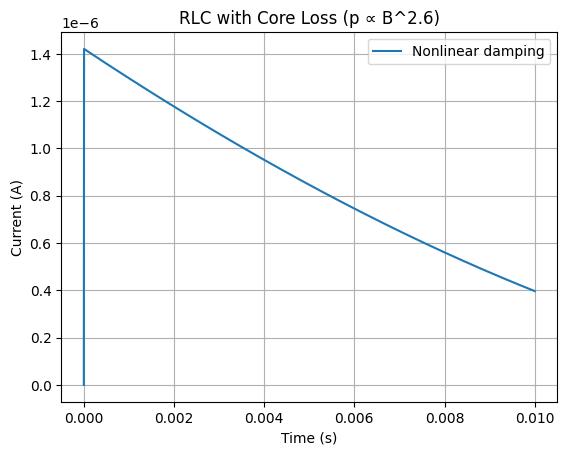

In [26]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -------------------------
# 1. Fit k from your data
# -------------------------
b = np.array([30,220]) * 1e-3   # Tesla
pv = np.array([4,700]) * 1e3    # W/m^3

beta = 2.6
k = np.mean(pv / (b**beta))   # your preferred method

print("k =", k)

# -------------------------
# 2. Circuit parameters
# -------------------------
L = 1e-3
C = 1e-6

# scale factor B = Kb * i (UNKNOWN → tune this!)
Kb = 1.0   # adjust based on core geometry

K = k * (Kb**beta)

# -------------------------
# 3. Nonlinear RLC model
# -------------------------
def rlc_nonlinear(t, y):
    i, di = y
    
    eps = 1e-12
    abs_i = abs(i) + eps
    
    # Equivalent nonlinear resistance
    Req = K * (abs_i**(beta - 2))   # = K * |i|^0.6
    
    # ODE
    d2i = -(Req/L)*di - (1/(L*C))*i
    
    return [di, d2i]

# -------------------------
# 4. Solve
# -------------------------
t_span = (0, 0.01)
t_eval = np.linspace(*t_span, 2000)

y0 = [0, 10]   # initial current and di/dt

sol = solve_ivp(rlc_nonlinear, t_span, y0, t_eval=t_eval)

# -------------------------
# 5. Plot
# -------------------------
plt.figure()
plt.plot(sol.t, sol.y[0], label="Nonlinear damping")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("RLC with Core Loss (p ∝ B^2.6)")
plt.grid()
plt.legend()

plt.show()

Keff = 0.09082073168527004


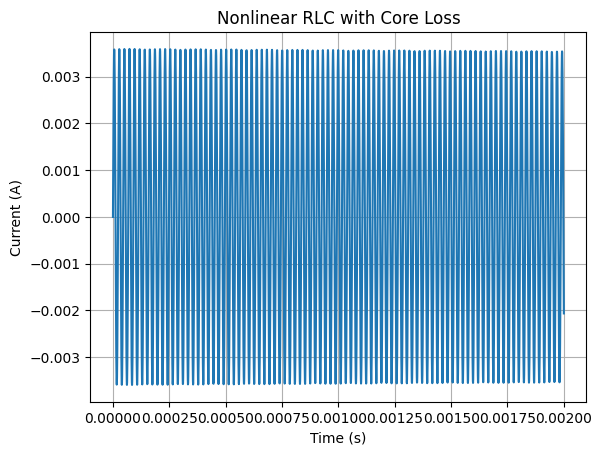

In [27]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -------------------------
# Given values
# -------------------------
L = 1.035e-4
C = 1.248e-7
k = 3.615638451882122e7

beta = 2.6

# -------------------------
# Scaling (CRITICAL)
# -------------------------
Vcore = 1e-6      # m^3 (example: small ferrite core)
Kb = 0.1          # Tesla per Amp (tunable)

Keff = k * Vcore * (Kb**beta)

print("Keff =", Keff)

# -------------------------
# Nonlinear RLC
# -------------------------
def rlc_nonlinear(t, y):
    i, di = y
    
    eps = 1e-12
    abs_i = abs(i) + eps
    
    # nonlinear resistance
    Req = Keff * (abs_i**(beta - 2))   # |i|^0.6
    
    d2i = -(Req/L)*di - (1/(L*C))*i
    
    return [di, d2i]

# -------------------------
# Solve
# -------------------------
t_span = (0, 0.002)
t_eval = np.linspace(*t_span, 3000)

y0 = [0, 1000]   # strong excitation

sol = solve_ivp(rlc_nonlinear, t_span, y0, t_eval=t_eval)

# -------------------------
# Plot
# -------------------------
plt.plot(sol.t, sol.y[0])
plt.title("Nonlinear RLC with Core Loss")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.grid()
plt.show()

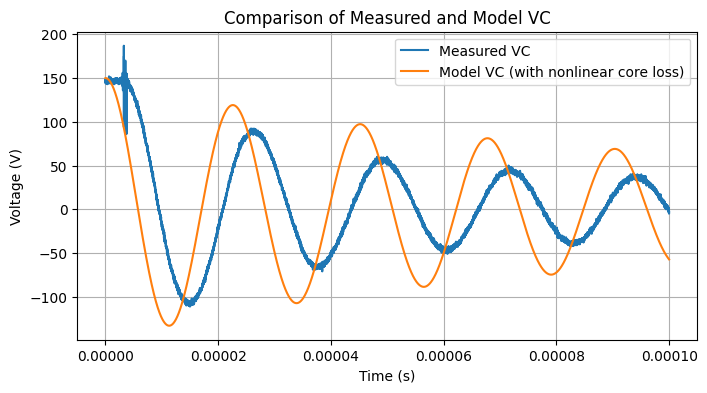

In [28]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --------------------------
# Given parameters
# --------------------------
L = 1.035e-4
C = 1.248e-7
VC0 = 150  # volts initial
k = 3.615638e7
beta = 2.6

Ae = 534.2e-6
Ve = 67745e-9
N = 4

# --------------------------
# Nonlinear RLC model
# --------------------------
def rlc_core_loss(t, y):
    i, VC, phi = y
    
    eps = 1e-12
    abs_i = abs(i) + eps
    
    # Flux density
    B = phi / (N * Ae)
    
    # Core loss
    Pv = k * Ve * (abs(B)**beta)
    
    # Nonlinear loss voltage
    Vloss = Pv / abs_i * np.sign(i)
    
    # ODEs
    di_dt = -(VC + Vloss) / L
    dVC_dt = i / C
    dphi_dt = L * di_dt  # phi = integral of L di/dt
    
    return [di_dt, dVC_dt, dphi_dt]

# --------------------------
# Initial conditions
# --------------------------
i0 = 0
phi0 = 0
y0 = [i0, VC0, phi0]

# Time span
t_span = (0, 0.002)
t_eval = df.time.values # np.linspace(*t_span, 2000)
t_span = (t_eval[0], t_eval[-1])    

# --------------------------
# Solve ODE
# --------------------------
sol = solve_ivp(rlc_core_loss, t_span, y0, t_eval=t_eval)

VC_model = sol.y[1]
t_model = sol.t

# --------------------------
# Plot comparison
# --------------------------
plt.figure(figsize=(8,4))
plt.plot(df.time, df.CH1, label="Measured VC")
plt.plot(t_model, VC_model, label="Model VC (with nonlinear core loss)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Comparison of Measured and Model VC")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
mask = df.CH1 > 180
i= mask[mask].index[0]
v0=df.CH1.loc[:i-10].mean()
df2=df.iloc[i:]

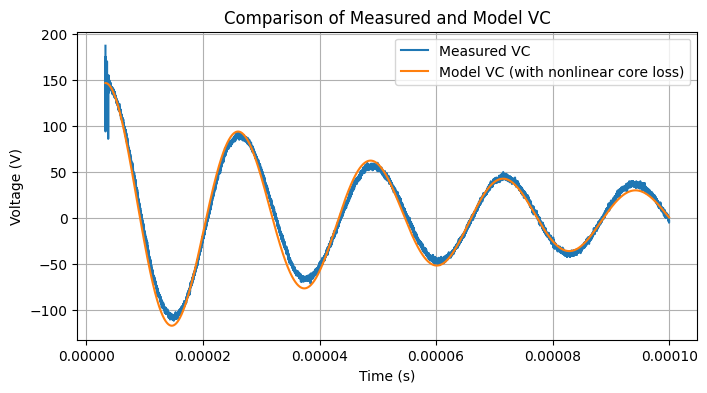

In [30]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --------------------------
# Given parameters
# --------------------------
# L = 73e-6 #1.035e-4
L = 1.035e-4*1.01
C = 1.248e-7
VC0 = v0# 150  # volts initial
k = 3.615638e7
#beta = 2.6
beta = 2.2

Ae = 534.2e-6
Ve = 67745e-9
N = 4

# --------------------------
# Nonlinear RLC model
# --------------------------
def rlc_core_loss(t, y):
    i, VC, phi = y
    
    eps = 1e-12
    abs_i = abs(i) + eps
    
    # Flux density
    B = phi / (N * Ae)
    
    # Core loss
    Pv = k * Ve * (abs(B)**beta)
    
    # Nonlinear loss voltage
    Vloss = Pv / abs_i * np.sign(i)
    
    # ODEs
    di_dt = -(VC + Vloss) / L
    dVC_dt = i / C
    dphi_dt = L * di_dt  # phi = integral of L di/dt
    
    return [di_dt, dVC_dt, dphi_dt]

# --------------------------
# Initial conditions
# --------------------------
i0 = 0
phi0 = 0
y0 = [i0, VC0, phi0]

# Time span
#t_span = (0, 0.002)
t_eval = df2.time.values # np.linspace(*t_span, 2000)
t_span = (t_eval[0], t_eval[-1])    

# --------------------------
# Solve ODE
# --------------------------
sol = solve_ivp(rlc_core_loss, t_span, y0, t_eval=t_eval)

VC_model = sol.y[1]
t_model = sol.t

# --------------------------
# Plot comparison
# --------------------------
plt.figure(figsize=(8,4))
plt.plot(df2.time, df2.CH1, label="Measured VC")
plt.plot(t_model, VC_model, label="Model VC (with nonlinear core loss)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Comparison of Measured and Model VC")
plt.grid(True)
plt.legend()
plt.show()

(1, 1000)

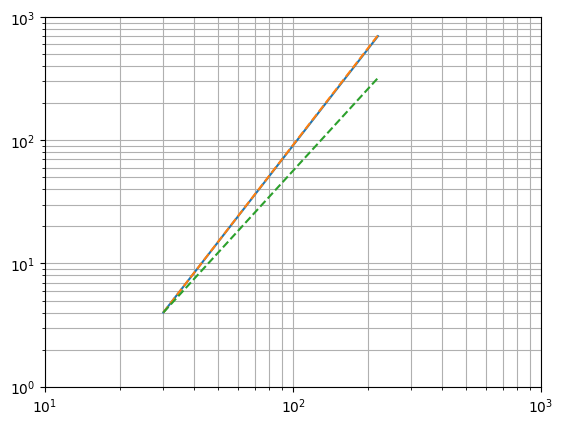

In [31]:
b=np.array([30,220]) # mT
pv=np.array([4,700])# kW/m3

# Pertes ∝ B_peak^2.6 (approximation Steinmetz)
pv2= b**2.6
# normalization
pv2=pv[0]*pv2/pv2[0]

plt.plot(b,pv)
plt.plot(b,pv2, linestyle= "--")


pv2= b**beta
# normalization
pv2=pv[0]*pv2/pv2[0]
plt.plot(b,pv2, linestyle= "--")


plt.xscale("log")
plt.yscale("log")
plt.grid(which="both")
plt.xlim([10,10**3])
plt.ylim([1,10**3])

### Lm 

**Tuned values**

In [40]:
%%render params
Lm_uH=Lm_uH # µH
Cr_nF =Cr_nF # nF
R=3 # Ω

<IPython.core.display.Latex object>

In [41]:
L = (Lm_uH)*1e-6

title=f"Comparison: Measurements vs Theoretical series LCR circuit\n"+\
f"L=Lr={L*1e6}µH; C=Cr={Cr_nF}nF; R={R}Ω"

In [42]:
#V0=pd.read_csv("05_LLC_resonance/2026-01-12_17-39-34-446.csv").CH1.mean()

In [43]:
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")

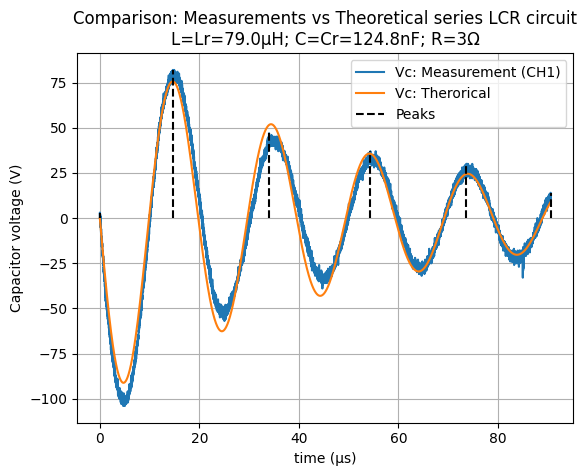

In [44]:

Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]


#Cr_nF =120
def dumpsin(t, Y0=10, phase = 0, L=L,C=Cr_nF*1e-9,R=R):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
#vc2= dumpsin(time,  Y0=-120, phase = 0, L=(79+24.5)*1e-6,C=1.04*120e-9,R=R)
vc2= dumpsin(time,  Y0=-100, phase = 0, L=L,C=Cr_nF*1e-9,R=R)
#vc2= dumpsin(time,  Y0=-125, phase = 0, L=(24.5)*1e-6,C=1.04*120e-9,R=0.4)
#vc2= dumpsin(time,  Y0=-100, phase = 0, L=(79)*1e-6,C=1.04*120e-9,R=3)
plt.title(title)

plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)")
plt.plot(time*1e6, vc2, label ="Vc: Therorical")
#plt.legend()
plt.grid()
plt.xlabel("time (µs)")
plt.ylabel("Capacitor voltage (V)")



from scipy.signal import find_peaks
inPeaks, properties = find_peaks(vc, height=0.5, distance=1000)
#mpeak = max(peak_values)
Peaks = properties["peak_heights"]
for P,i in zip(Peaks[:], inPeaks[:]): 
    if i < inPeaks[-1]:
        plt.plot([time[i]*1e6,time[i]*1e6], [0, P], c="k", linestyle="--")
    else: 
        plt.plot([time[i]*1e6,time[i]*1e6], [0,P], c="k", linestyle="--", label="Peaks")

plt.legend()


plt.show()



vc = vl = vr 
ic = il + ir 
c dv/dt = il + v/r 
lc d2v/dt2 = l dil/dt + l/r dv/dt
lc dv2/dt2 = v + l/r dv/dt

ic = cdv/dt 
v = l dil/dt = N dflux /dt = N A dB(i)/dt


Solver status: Required step size is less than spacing between numbers.  (75 internal steps)


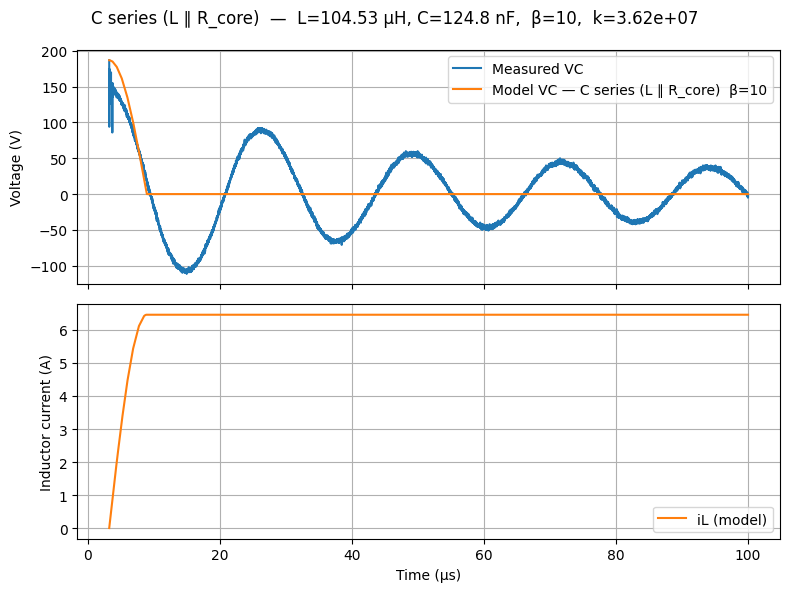

In [46]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Topology: C in series with (L || R_nonlinear)
#
# KVL around the loop (no source):
#   V_{L||R} = VC
#
# KCL at the parallel node:
#   i_C = iL + iR
#   dVC/dt = -(iL + iR) / C       ← negative: C discharges into L||R
#
# Inductor:
#   diL/dt = V_L / L = VC / L
#
# Flux linkage (lambda = N * Phi):
#   dphi/dt = V_L = VC
#   B = phi / (N * Ae)
#
# Nonlinear parallel loss resistor (Steinmetz):
#   Pcore = k * Ve * |B|^beta      [W]
#   iR = Pcore / |VC|  * sign(VC)  power balance in parallel branch
# ---------------------------------------------------------------

# --- circuit parameters (reuse from above) ---
L_par  = 1.035e-4 * 1.01   # H
C_par  = 1.248e-7           # F

# --- core / Steinmetz ---
Ae_par = 534.2e-6   # m^2
Ve_par = 67745e-9   # m^3
N_par  = 4
k_par  = 3.615638e7
beta_par = 10

# --- measured data ---
t_meas_par  = df2.time.values
VC_meas_par = df2.CH1.values
VC0_par     = VC_meas_par[0]


def rlc_C_series_LparR(t, y):
    iL, VC, phi = y
    eps = 1e-12

    # flux density
    B   = phi / (N_par * Ae_par)

    # Steinmetz loss power → equivalent parallel current
    Pv  = k_par * Ve_par * (abs(B) ** beta_par)
    iR  = Pv / (abs(VC) + eps) * np.sign(VC)

    # ODEs
    diL_dt  =  VC / L_par               # V_L = VC  (KVL)
    dVC_dt  = -(iL + iR) / C_par        # KCL  (C discharges)
    dphi_dt =  VC                        # dphi/dt = V_L = VC

    return [diL_dt, dVC_dt, dphi_dt]


# --- solve: let solver pick its own time steps, then interpolate ---
y0     = [0.0, VC0_par, 0.0]
t_span = (t_meas_par[0], t_meas_par[-1])

sol = solve_ivp(
    rlc_C_series_LparR, t_span, y0,
    method='RK45', rtol=1e-6, atol=1e-9
)

# interpolate model onto the measured time grid
VC_model_par = np.interp(t_meas_par, sol.t, sol.y[1])
iL_model_par = np.interp(t_meas_par, sol.t, sol.y[0])

print(f"Solver status: {sol.message}  ({len(sol.t)} internal steps)")

# --- plot ---
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(t_meas_par * 1e6, VC_meas_par, label="Measured VC")
axs[0].plot(t_meas_par * 1e6, VC_model_par, label=f"Model VC — C series (L ∥ R_core)  β={beta_par}")
axs[0].set_ylabel("Voltage (V)")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t_meas_par * 1e6, iL_model_par, label="iL (model)", color="tab:orange")
axs[1].set_ylabel("Inductor current (A)")
axs[1].set_xlabel("Time (µs)")
axs[1].legend()
axs[1].grid(True)

plt.suptitle(
    f"C series (L ∥ R_core)  —  L={L_par*1e6:.2f} µH, "
    f"C={C_par*1e9:.1f} nF,  β={beta_par},  k={k_par:.2e}"
)
plt.tight_layout()
plt.show()


In [50]:
Ae, N

(0.0005342, 4)

The solver successfully reached the end of the integration interval.  (157 steps)


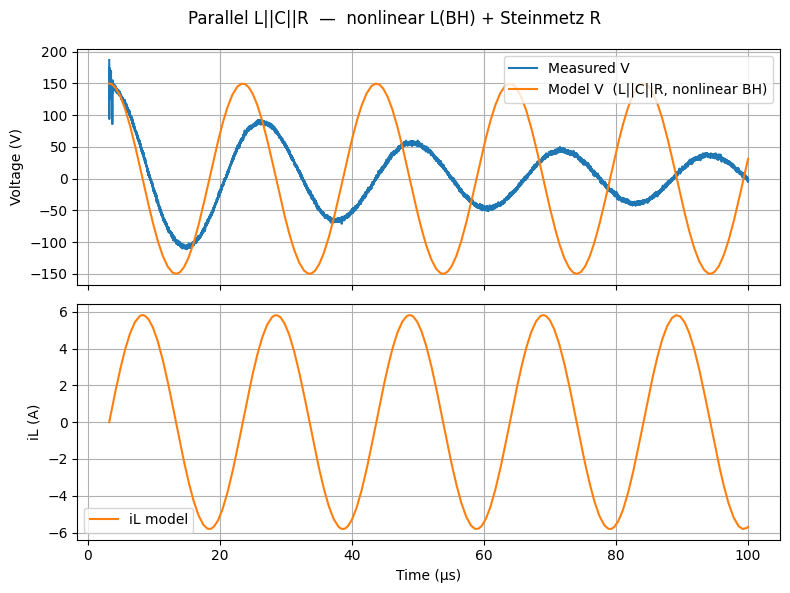

In [69]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Topology: L || C || R  (3 in parallel, same voltage V)
#
# KCL:  C*dV/dt = -(iL + iR)       [C discharges into L and R]
#
# Nonlinear L via BH curve:
#   V = N*Ae * dB/dt = N*Ae * (dB/diL) * diL/dt
#   => diL/dt = V / (N*Ae * dB_diL(iL))
#
# Steinmetz R (instantaneous power balance):
#   Pv [W/m³] = k * |B(iL)|^beta
#   iR = k*Ve*|B|^beta / |V| * sign(V)
# ---------------------------------------------------------------

# --- BH curve: *** REPLACE with your measured arrays ***
# i_BH in Amperes, B_BH in Tesla, must be sorted by i
i_BH = np.linspace(-10, 10, 500)
# B_BH = 0.35 * np.tanh(i_BH / 2)          # placeholder saturation curve
B_BH = 83e-6*i_BH /(Ae*N)
# precompute slope dB/di on the grid
dBdi_BH = np.gradient(B_BH, i_BH)

def B_of_i(iL):     return np.interp(iL, i_BH, B_BH)
def dBdi_of_i(iL):  return np.interp(iL, i_BH, dBdi_BH)

# --- parameters ---
C_    = 1.248e-7   # F
N_    = 4
Ae_   = 534.2e-6   # m²
Ve_   = 67745e-9   # m³
k_    = 0.78*1e-5*3.615638e7 # Steinmetz k [W·m⁻³·T⁻ᵝ]
beta_ = 2.2
eps   = 1e-12

# --- ODE: state = [V, iL] ---
def parallel_LCR(t, y):
    V, iL = y

    B     = B_of_i(iL)
    dBdi  = max(float(abs(dBdi_of_i(iL))), eps)   # positive, avoid /0

    Pv    = k_ * Ve_ * abs(B)**beta_
    iR    = Pv / (abs(V) + eps) * np.sign(V)

    dV_dt  = -(iL + iR) / C_
    diL_dt =  V / (N_ * Ae_ * dBdi)

    return [dV_dt, diL_dt]

# --- measured data & initial conditions ---
t_meas_ = df2.time.values
V_meas_ = df2.CH1.values
y0_     = [V_meas_[0], 0.0]
y0_     = [150, 0.0]
t_span_ = (t_meas_[0], t_meas_[-1])

sol_ = solve_ivp(parallel_LCR, t_span_, y0_, method='RK45', rtol=1e-6, atol=1e-9)

V_model_  = np.interp(t_meas_, sol_.t, sol_.y[0])
iL_model_ = np.interp(t_meas_, sol_.t, sol_.y[1])

print(f"{sol_.message}  ({len(sol_.t)} steps)")

# --- plot ---
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(t_meas_*1e6, V_meas_,  label="Measured V")
axs[0].plot(t_meas_*1e6, V_model_, label="Model V  (L||C||R, nonlinear BH)")
axs[0].set_ylabel("Voltage (V)"); axs[0].legend(); axs[0].grid()
axs[1].plot(t_meas_*1e6, iL_model_, color="tab:orange", label="iL model")
axs[1].set_ylabel("iL (A)"); axs[1].set_xlabel("Time (µs)"); axs[1].legend(); axs[1].grid()
plt.suptitle("Parallel L||C||R  —  nonlinear L(BH) + Steinmetz R")
plt.tight_layout(); plt.show()


In [68]:
[V_meas_[0], 0.0]

[np.float64(187.0), 0.0]

f0     = 43.85 kHz
G3     = 3.8486e-04  A/V^1.6
iR(185V) = 1.63 A   P = 302.0 W
The solver successfully reached the end of the integration interval.  (227 steps)


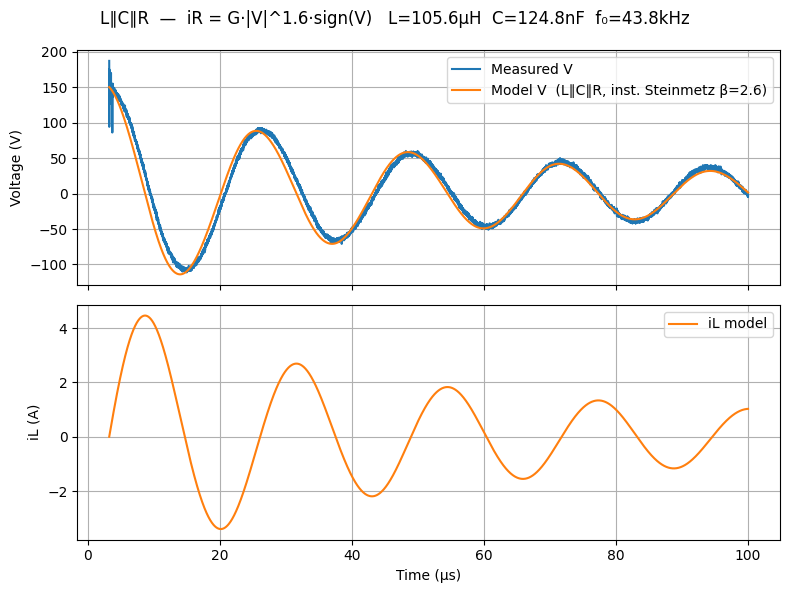

In [80]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Topology: L || C || R_core  (all 3 in parallel, same voltage V)
# KCL:  C*dV/dt = -(iL + iR)
# iL :  diL/dt  = V / L
#
# WHY iR = P/|V| was wrong:
#   at every zero-crossing V→0  →  iR→∞  →  all energy absorbed instantly
#   Steinmetz gives AVERAGE power per cycle, not instantaneous power.
#
# FIX — instantaneous Steinmetz via dB/dt:
#   V = N*Ae * dB/dt   =>   dB/dt = V / (N*Ae)
#   p_v(t) = k * |dB/dt / ω₀|^β   [W/m³]
#          = k/ω₀^β * | V/(N*Ae) |^β
#   P_core = p_v * Ve
#   iR = P_core / V  =  G * |V|^(β-1) * sign(V)
#
#   where  G = k*Ve / (ω₀*N*Ae)^β
#
#   => iR = 0 when V = 0  (no singularity → circuit oscillates!)
# ---------------------------------------------------------------

L3    = 1.035e-4 * 1.02
C3    = 1.248e-7
N3    = 4
Ae3   = 534.2e-6   # m²
Ve3   = 67745e-9   # m³
k3    = 3.615638e7*2.5
beta3 = 2.6

omega0_3 = 1.0 / np.sqrt(L3 * C3)           # natural frequency [rad/s]

# conductance pre-factor:  iR = G3 * |V|^(beta3-1) * sign(V)
G3 = k3 * Ve3 / (omega0_3 * N3 * Ae3) ** beta3

print(f"f0     = {omega0_3/(2*np.pi)/1e3:.2f} kHz")
print(f"G3     = {G3:.4e}  A/V^{beta3-1:.1f}")
print(f"iR(185V) = {G3 * 185**(beta3-1):.2f} A   P = {G3*185**beta3:.1f} W")

# --- measured data ---
t_m3 = df2.time.values
V_m3 = df2.CH1.values

def ode_parallel(t, y):
    V, iL = y
    iR     = G3 * abs(V)**(beta3 - 1) * np.sign(V)
    dV_dt  = -(iL + iR) / C3
    diL_dt =  V / L3
    return [dV_dt, diL_dt]

sol3 = solve_ivp(ode_parallel,
                 (t_m3[0], t_m3[-1]), 
                 #[V_m3[0], 0.0],
                 [150, 0.0],
                 method='RK45', rtol=1e-7, atol=1e-10,
                 dense_output=True)

V_mod3  = sol3.sol(t_m3)[0]
iL_mod3 = sol3.sol(t_m3)[1]
print(f"{sol3.message}  ({len(sol3.t)} steps)")

# --- plot ---
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(t_m3*1e6, V_m3,    label="Measured V")
axs[0].plot(t_m3*1e6, V_mod3,  label=f"Model V  (L∥C∥R, inst. Steinmetz β={beta3})")
axs[0].set_ylabel("Voltage (V)"); axs[0].legend(); axs[0].grid()
axs[1].plot(t_m3*1e6, iL_mod3, color="tab:orange", label="iL model")
axs[1].set_ylabel("iL (A)"); axs[1].set_xlabel("Time (µs)")
axs[1].legend(); axs[1].grid()
plt.suptitle(
    f"L∥C∥R  —  iR = G·|V|^{beta3-1:.1f}·sign(V)   "
    f"L={L3*1e6:.1f}µH  C={C3*1e9:.1f}nF  f₀={omega0_3/(2*np.pi)/1e3:.1f}kHz"
)
plt.tight_layout()
plt.show()


In [81]:
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")

<Axes: >

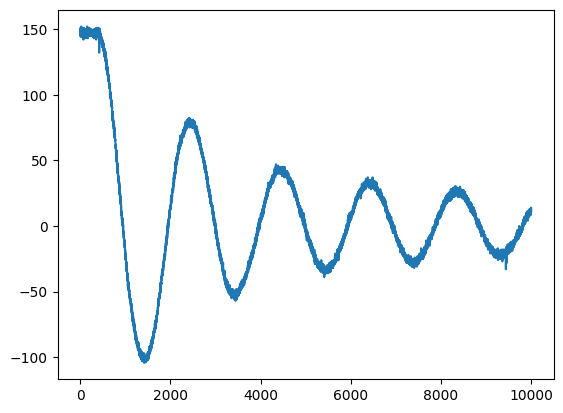

In [84]:
df.CH1.plot()

In [85]:
df2= df.copy()

f0     = 50.69 kHz
G3     = 2.8697e-03  A/V^1.2
iR(185V) = 1.51 A   P = 279.0 W
The solver successfully reached the end of the integration interval.  (284 steps)


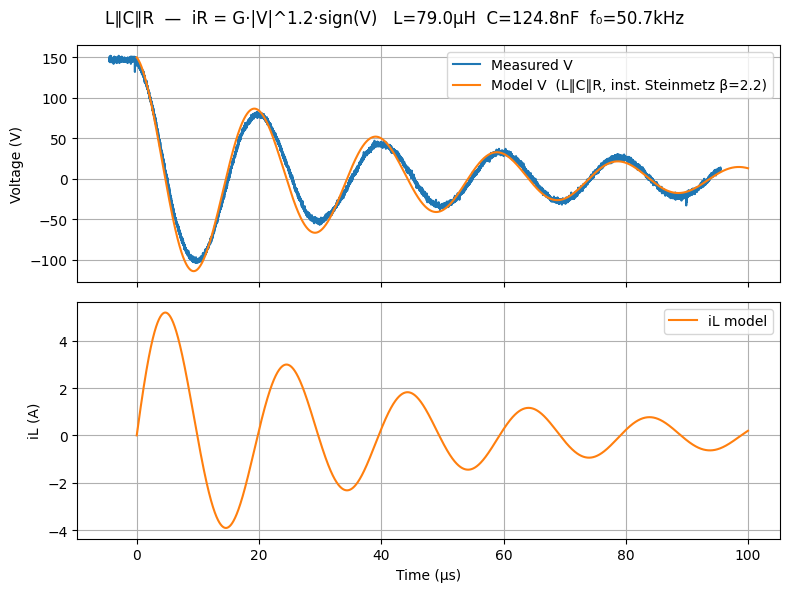

In [119]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Topology: L || C || R_core  (all 3 in parallel, same voltage V)
# KCL:  C*dV/dt = -(iL + iR)
# iL :  diL/dt  = V / L
#
# WHY iR = P/|V| was wrong:
#   at every zero-crossing V→0  →  iR→∞  →  all energy absorbed instantly
#   Steinmetz gives AVERAGE power per cycle, not instantaneous power.
#
# FIX — instantaneous Steinmetz via dB/dt:
#   V = N*Ae * dB/dt   =>   dB/dt = V / (N*Ae)
#   p_v(t) = k * |dB/dt / ω₀|^β   [W/m³]
#          = k/ω₀^β * | V/(N*Ae) |^β
#   P_core = p_v * Ve
#   iR = P_core / V  =  G * |V|^(β-1) * sign(V)
#
#   where  G = k*Ve / (ω₀*N*Ae)^β
#
#   => iR = 0 when V = 0  (no singularity → circuit oscillates!)
# ---------------------------------------------------------------

L3    = 79e-6
C3    = 1.248e-7
N3    = 4
Ae3   = 534.2e-6   # m²
Ve3   = 67745e-9   # m³
k3    = 3.615638e7*2
beta3 = 2.2

omega0_3 = 1.0 / np.sqrt(L3 * C3)           # natural frequency [rad/s]

# conductance pre-factor:  iR = G3 * |V|^(beta3-1) * sign(V)
G3 = k3 * Ve3 / (omega0_3 * N3 * Ae3) ** beta3

print(f"f0     = {omega0_3/(2*np.pi)/1e3:.2f} kHz")
print(f"G3     = {G3:.4e}  A/V^{beta3-1:.1f}")
print(f"iR(185V) = {G3 * 185**(beta3-1):.2f} A   P = {G3*185**beta3:.1f} W")

# --- measured data ---
t_m3 = df2.time.values
V_m3 = df2.CH1.values

def ode_parallel(t, y):
    V, iL = y
    iR     = G3 * abs(V)**(beta3 - 1) * np.sign(V)
    dV_dt  = -(iL + iR) / C3
    diL_dt =  V / L3
    return [dV_dt, diL_dt]

sol3 = solve_ivp(ode_parallel,
                 (t_m3[0], t_m3[-1]), 
                 #[V_m3[0], 0.0],
                 [150, 0.0],
                 method='RK45', rtol=1e-7, atol=1e-10,
                 dense_output=True)

V_mod3  = sol3.sol(t_m3)[0]
iL_mod3 = sol3.sol(t_m3)[1]
print(f"{sol3.message}  ({len(sol3.t)} steps)")

# --- plot ---
n0=450
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot((t_m3*1e6)-1e6*Ts*n0, V_m3,    label="Measured V")
axs[0].plot(t_m3*1e6, V_mod3,  label=f"Model V  (L∥C∥R, inst. Steinmetz β={beta3})")
axs[0].set_ylabel("Voltage (V)"); axs[0].legend(); axs[0].grid()
axs[1].plot(t_m3*1e6, iL_mod3, color="tab:orange", label="iL model")
axs[1].set_ylabel("iL (A)"); axs[1].set_xlabel("Time (µs)")
axs[1].legend(); axs[1].grid()
plt.suptitle(
    f"L∥C∥R  —  iR = G·|V|^{beta3-1:.1f}·sign(V)   "
    f"L={L3*1e6:.1f}µH  C={C3*1e9:.1f}nF  f₀={omega0_3/(2*np.pi)/1e3:.1f}kHz"
)
plt.tight_layout()
plt.show()


In [114]:
Ts= df.Ts.iloc[0]
5e-6/Ts, Ts*n0

(np.float64(500.00000000000006), np.float64(5e-06))

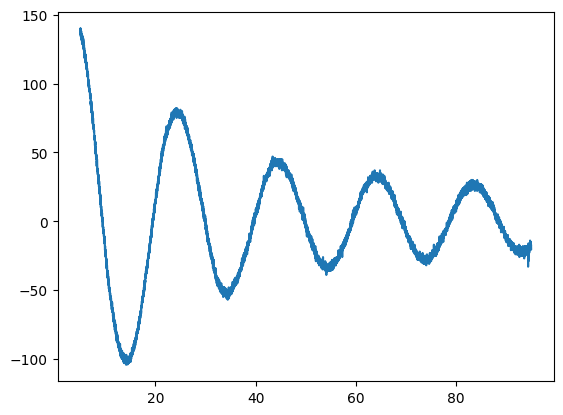

In [110]:
plt.plot((t_m3*1e6)[n0:-n0], V_m3[n0:-n0],    label="Measured V")

### Lm , find optimal values 

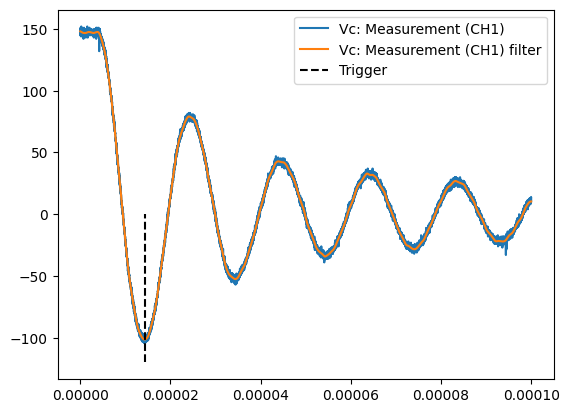

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

L, C, R=(7.9e-05, 1.2408e-07, 3)
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
#idx= trigger(vc, transition='fall', thresh=0)[0]

#vc= vc[idx:]


time  =np.arange(0, len(vc)*Ts, Ts)




fs = 1 / Ts          # sampling frequency
fc = 1e6          # cutoff frequency (Hz)
order = 4
# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
# zero-phase filtering
vcf= signal.sosfiltfilt(sos, vc)

from scipy.signal import find_peaks
inPeaks, properties = find_peaks(-vcf, height=0.5, distance=1000)


plt.plot(time, vc, label="Vc: Measurement (CH1)")
plt.plot(time, vcf, label="Vc: Measurement (CH1) filter")
t0= time[inPeaks[0]]
plt.plot([t0, t0], [-120, 0], c="k", linestyle="--", label="Trigger")
#plt.plot(time*1e6, vc2, label ="Vc: Therorical")
plt.legend()


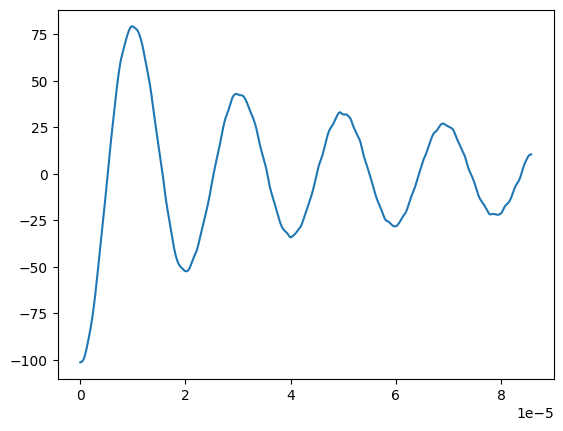

In [13]:
t= time[inPeaks[0]:]
t= t-t[0]
vcf2= vcf[inPeaks[0]:]
plt.plot(t, vcf2, label="Vc: Measurement (CH1) filter")

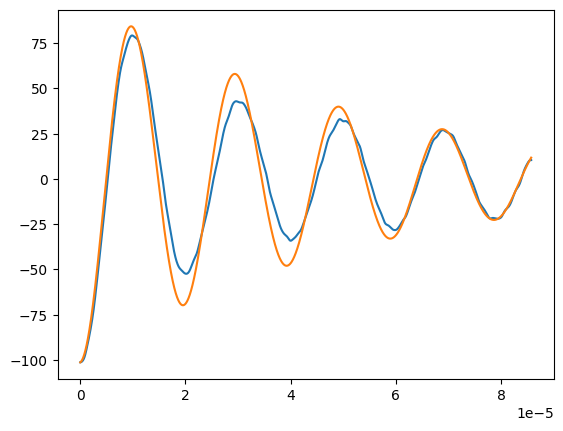

In [16]:
def dumpsin(t, Y0=10, phase = 0, L=L,C=C,R=R):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.cos(wd*t-phase)

vc2= dumpsin(t,  Y0=vcf2[0], phase = 0, L=L,C=C,R=R)
plt.plot(t, vcf2, label="Vc: Measurement (CH1) filter")
plt.plot(t, vc2, label="Vc: Measurement (CH1) filter")


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 295979.72143502545
             x: [ 3.233e+00  6.560e-05  1.542e-07]
           nit: 63
          nfev: 120
 final_simplex: (array([[ 3.233e+00,  6.560e-05,  1.542e-07],
                       [ 3.233e+00,  6.560e-05,  1.542e-07],
                       [ 3.233e+00,  6.560e-05,  1.542e-07],
                       [ 3.233e+00,  6.560e-05,  1.542e-07]]), array([ 2.960e+05,  2.960e+05,  2.960e+05,  2.960e+05]))
Optimized parameters: R=3.23 Ω, L=65.60 µH, C=154.21 nF


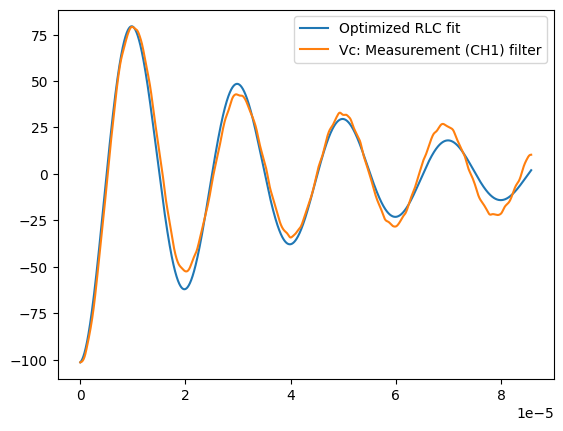

In [18]:
def object(x):
    R, L, C = x
    vc2= dumpsin(t,  Y0=vcf2[0], phase = 0, L=L,C=C,R=R)
    return np.sum((vc2-vcf2)**2)
x0= [R, L, C]
from scipy.optimize import minimize 
res = minimize(object, x0, method='Nelder-Mead')
print(res)
R_opt, L_opt, C_opt = res.x
print(f"Optimized parameters: R={R_opt:.2f} Ω, L={L_opt*1e6:.2f} µH, C={C_opt*1e9:.2f} nF")
vc2_opt= dumpsin(t,  Y0=vcf2[0], phase = 0, L=L_opt,C=C_opt,R=R_opt)
plt.plot(t, vc2_opt, label="Optimized RLC fit")
plt.plot(t, vcf2, label="Vc: Measurement (CH1) filter")
plt.legend()

[(2.25, 4.5), (3.95e-05, 0.0001185), (6.204e-08, 1.8612000000000003e-07)]
             message: Optimization terminated successfully.
             success: True
                 fun: 295979.7213928852
                   x: [ 3.750e+00  7.609e-05  1.330e-07]
                 nit: 90
                nfev: 4179
          population: [[ 3.750e+00  7.609e-05  1.330e-07]
                       [ 3.749e+00  7.608e-05  1.330e-07]
                       ...
                       [ 3.750e+00  7.609e-05  1.329e-07]
                       [ 3.758e+00  7.627e-05  1.326e-07]]
 population_energies: [ 2.960e+05  2.960e+05 ...  2.960e+05  2.960e+05]
DE optimized: R=3.750 Ω,  L=76.09 µH,  C=132.95 nF


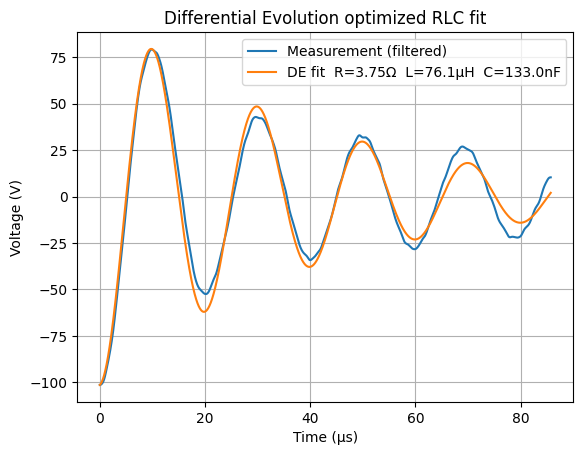

In [22]:

from scipy.optimize import differential_evolution

# Bounds: (R [Ω], L [H], C [F])
bounds = [
    (R*0.75,  R*1.5),          # R
    (L*0.5,  L*1.5),       # L
    (C*0.5,  C*1.5),      # C
]
print(bounds)

def objective_de(x):
    R_, L_, C_ = x
    vc2 = dumpsin(t, Y0=vcf2[0], phase=0, L=L_, C=C_, R=R_)
    return np.sum((vc2 - vcf2) ** 2)

res_de = differential_evolution(
    objective_de,
    bounds,
    seed=42,
    maxiter=1000,
    tol=1e-10,
    workers=1,
    polish=True,      # final L-BFGS-B refinement within bounds
    disp=False,
)

print(res_de)
R_de, L_de, C_de = res_de.x
print(f"DE optimized: R={R_de:.3f} Ω,  L={L_de*1e6:.2f} µH,  C={C_de*1e9:.2f} nF")

vc2_de = dumpsin(t, Y0=vcf2[0], phase=0, L=L_de, C=C_de, R=R_de)
plt.figure()
plt.plot(t * 1e6, vcf2,   label="Measurement (filtered)")
plt.plot(t * 1e6, vc2_de, label=f"DE fit  R={R_de:.2f}Ω  L={L_de*1e6:.1f}µH  C={C_de*1e9:.1f}nF")
plt.xlabel("Time (µs)")
plt.ylabel("Voltage (V)")
plt.title("Differential Evolution optimized RLC fit")
plt.legend()
plt.grid()
plt.show()


#### Parallel RLC 

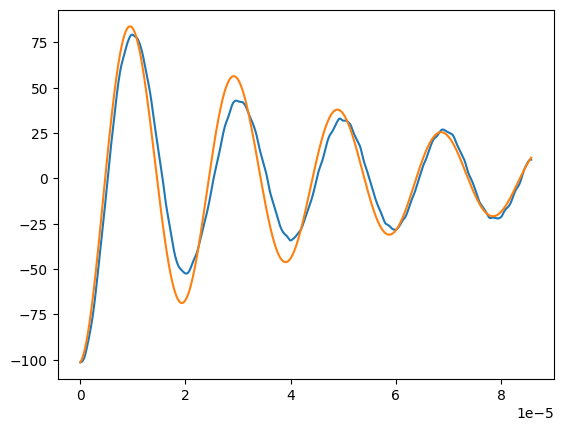

In [29]:
def dumpsin_par(t, Y0=10, phase=0, L=L, C=C, R=R):
    w0    = 1 / np.sqrt(L * C)
    m     = (1 / (2 * R)) * np.sqrt(L / C)   # damping ratio — parallel RLC
    alpha = w0 * m
    wd    = w0 * np.sqrt(1 - m * m)
    phi   = np.arctan2(alpha, wd)             # phase correction: iL(0)=0
    return Y0 * (w0 / wd) * np.exp(-alpha * t) * np.cos(wd * t + phi - phase)
Rp=200
vc2= dumpsin_par(t,  Y0=vcf2[0], phase = 0, L=L,C=C,R=Rp)
plt.plot(t, vcf2, label="Vc: Measurement (CH1) filter")
plt.plot(t, vc2, label="Vc: Measurement (CH1) filter")

[(150.0, 300.0), (3.95e-05, 0.0001185), (6.204e-08, 1.8612000000000003e-07)]
             message: Optimization terminated successfully.
             success: True
                 fun: 430117.7250655204
                   x: [ 2.134e+02  1.070e-04  9.581e-08]
                 nit: 79
                nfev: 3684
          population: [[ 2.134e+02  1.070e-04  9.581e-08]
                       [ 2.134e+02  1.070e-04  9.582e-08]
                       ...
                       [ 2.134e+02  1.070e-04  9.581e-08]
                       [ 2.133e+02  1.070e-04  9.584e-08]]
 population_energies: [ 4.301e+05  4.301e+05 ...  4.301e+05  4.301e+05]
DE optimized: R=213.383 Ω,  L=106.99 µH,  C=95.81 nF


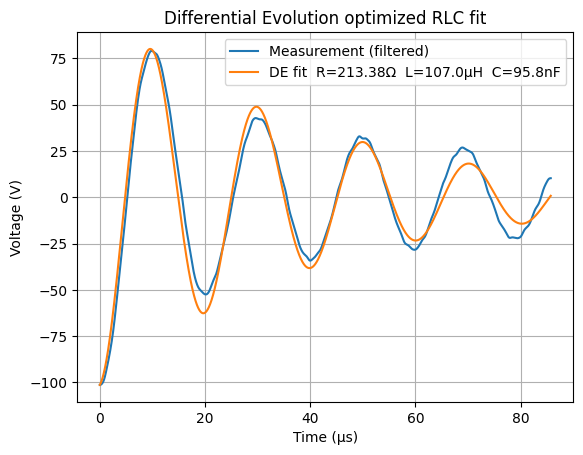

In [31]:

from scipy.optimize import differential_evolution

# Bounds: (R [Ω], L [H], C [F])
bounds = [
    (Rp*0.75,  Rp*1.5),          # R
    (L*0.5,  L*1.5),       # L
    (C*0.5,  C*1.5),      # C
]
print(bounds)

def objective_de(x):
    R_, L_, C_ = x
    #vc2 = dumpsin(t, Y0=vcf2[0], phase=0, L=L_, C=C_, R=R_)
    vc2= dumpsin_par(t,  Y0=vcf2[0], phase = 0, L=L_,C=C_,R=R_)
    return np.sum((vc2 - vcf2) ** 2)

res_de = differential_evolution(
    objective_de,
    bounds,
    seed=42,
    maxiter=1000,
    tol=1e-10,
    workers=1,
    polish=True,      # final L-BFGS-B refinement within bounds
    disp=False,
)

print(res_de)
R_de, L_de, C_de = res_de.x
print(f"DE optimized: R={R_de:.3f} Ω,  L={L_de*1e6:.2f} µH,  C={C_de*1e9:.2f} nF")

vc2_de = dumpsin_par(t, Y0=vcf2[0], phase=0, L=L_de, C=C_de, R=R_de)
plt.figure()
plt.plot(t * 1e6, vcf2,   label="Measurement (filtered)")
plt.plot(t * 1e6, vc2_de, label=f"DE fit  R={R_de:.2f}Ω  L={L_de*1e6:.1f}µH  C={C_de*1e9:.1f}nF")
plt.xlabel("Time (µs)")
plt.ylabel("Voltage (V)")
plt.title("Differential Evolution optimized RLC fit")
plt.legend()
plt.grid()
plt.show()
